In [1]:
import torch
import matplotlib.pyplot as plt
from util import load_model, load_config, value_factor, cove
from model import VFNN
from util import load_dataset, load_dataset_no_split, load_experiment
import pandas as pd
import numpy as np
from classical_strategies import base_load, base_load_modified
from tabulate import tabulate

In [2]:
model_1day_10, raw_dataset, config = load_experiment('a73d6466-5da1-40a1-a3be-7e9377409fb0', '../../data/processed/dataset_2018-21_clean.csv')
model_1day_5, _, _ = load_experiment('b4705a69-aa70-4861-9d78-bc5c7a609f8f', '../../data/processed/dataset_2018-21_clean.csv')
model_1day_4, _, _ = load_experiment('9ffe020a-aabe-4cff-a07b-90e0a6f75702', '../../data/processed/dataset_2018-21_clean.csv')
model_1day_3, _, _ = load_experiment('5860903f-10af-4971-9f9a-14e813385ff5', '../../data/processed/dataset_2018-21_clean.csv')
model_1day_1, _, _ = load_experiment('9c82f6d8-280b-43f8-abbf-90b3d1a1a698', '../../data/processed/dataset_2018-21_clean.csv')
model_1day_0, _, _ = load_experiment('f60475b0-82d0-417a-9bf1-e141a975e556', '../../data/processed/dataset_2018-21_clean.csv')

/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = th

Length of dataset: 24


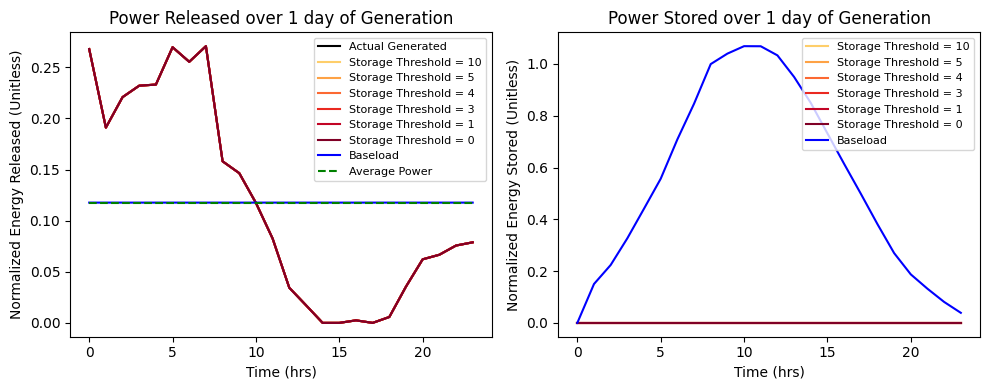

Length of dataset: 168


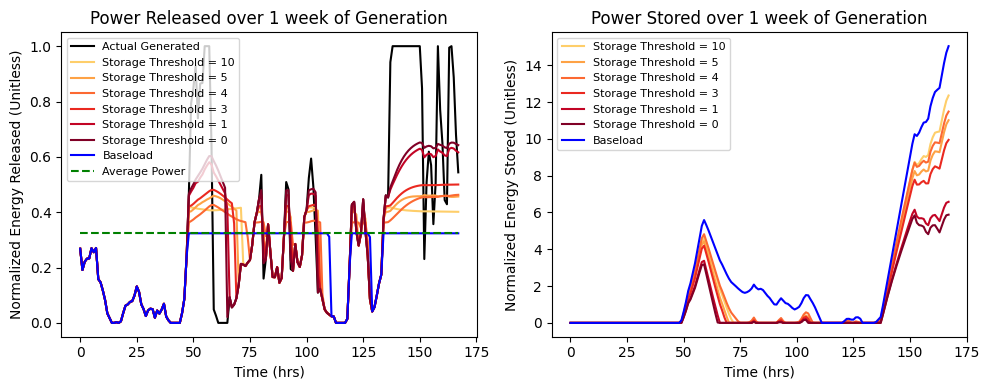

Length of dataset: 720


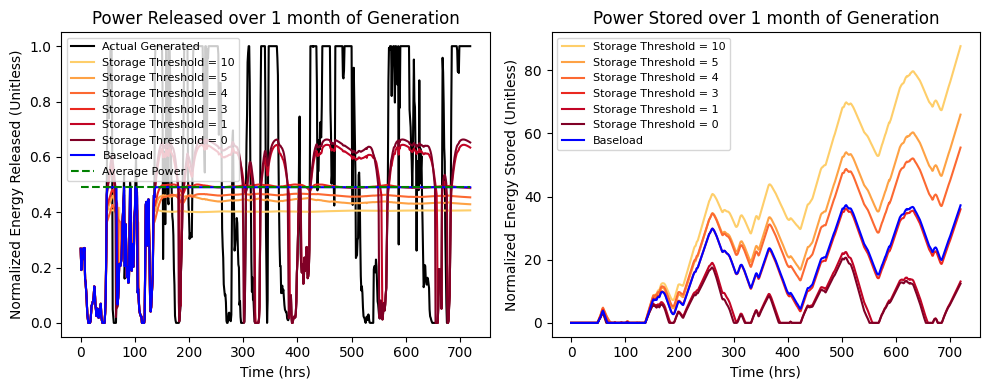

Length of dataset: 8760


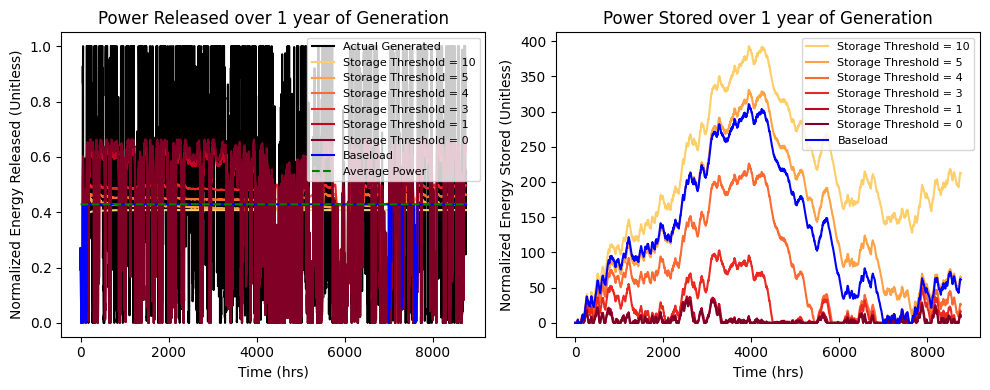

Length of dataset: 34861


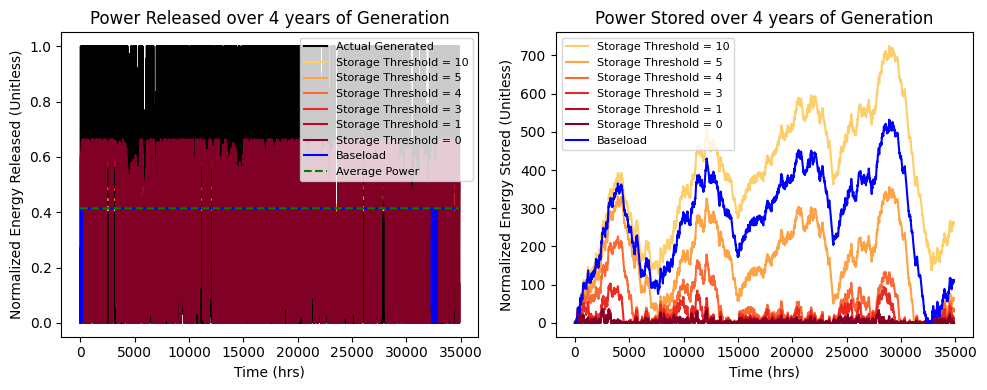

In [3]:
# Time scales for applying strategy
scales = ['1 day', '1 week', '1 month', '1 year', '4 years']
upper_dataset_bounds = [24, 24 * 7, 24 * 30, 24 * 365, len(raw_dataset)]

# Models available to test against (excluding baseline)
models = [model_1day_10, model_1day_5, model_1day_4, model_1day_3, model_1day_1, model_1day_0]
model_storage_thresholds = [10, 5, 4, 3, 1, 0]

S = len(scales)
M = len(models)

# We compute these M+2 times because we compute the VF,COVE for each model, as well as for the raw power and baseload
vfs = np.zeros(shape=(S, M+2))
coves = np.zeros(shape=(S, M+2))

for i in range(S):
    upper_dataset_bound = upper_dataset_bounds[i]
    scale = scales[i]
    dataset = raw_dataset[:upper_dataset_bound]
    print(f'Length of dataset: {len(dataset)}')
    power = dataset[:,0].detach().cpu().numpy().squeeze()
    price = dataset[:,1].detach().cpu().numpy().squeeze()
    x = np.arange(0, len(dataset))

    #Compute raw VF and COVE (no storage)
    vfs[i, 0] = value_factor(power, price)
    coves[i, 0] = cove(power, price)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    cmap = plt.get_cmap('YlOrRd', M + 2)

    avg_power = np.repeat(np.mean(power), len(x))
    ax1.plot(x, power, 'black', label='Actual Generated')
    for j in range(M):
        model = models[j]
        model_storage_threshold = model_storage_thresholds[j]

        pred = model(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
        released = pred[:,0]
        stored = pred[:,1]

        #Compute VF and COVE with storage strategy
        vfs[i, j+1] = value_factor(released, price)
        coves[i, j+1] = cove(released, price)

        ax1.plot(x, released, color=cmap(j + 2), label=f'Storage Threshold = {model_storage_threshold}')
        ax2.plot(x, stored, color=cmap(j + 2), label=f'Storage Threshold = {model_storage_threshold}')
    # Get baseload performance
    baseload_released, baseload_stored = base_load(power)
    #Compute VF and COVE with baseload strategy
    vfs[i, M+1] = value_factor(baseload_released, price)
    coves[i, M+1] = cove(baseload_released, price)
    ax1.plot(x, baseload_released, 'b', label='Baseload')
    ax2.plot(x, baseload_stored, 'b', label='Baseload')
    # Display average power over other curves
    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Normalized Energy Released (Unitless)')
    ax1.set_title(f'Power Released over {scale} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Normalized Energy Stored (Unitless)')
    ax2.set_title(f'Power Stored over {scale} of Generation')
    ax2.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [4]:
strategy_names = ["Raw", "COVE-NN-10", "COVE-NN-5", "COVE-NN-4", "COVE-NN-3", "COVE-NN-1", "COVE-NN-0", "Baseload"]
for i in range(S):
    print(f'Performance for {scales[i]} of power generation')
    metrics = {
        'Strategy': strategy_names,
        'VF': vfs[i,:],
        'COVE': coves[i,:],
        'Beats Baseload in VF?': vfs[i,:] < vfs[i,-1],
        'Beats Baseload in COVE?': coves[i,:] < coves[i,-1]
    }
    df = pd.DataFrame(metrics)
    print(tabulate(df, headers='keys', tablefmt='psql'))

Performance for 1 day of power generation
+----+------------+----------+---------+-------------------------+---------------------------+
|    | Strategy   |       VF |    COVE | Beats Baseload in VF?   | Beats Baseload in COVE?   |
|----+------------+----------+---------+-------------------------+---------------------------|
|  0 | Raw        | 0.943004 | 10.8424 | True                    | False                     |
|  1 | COVE-NN-10 | 0.943004 | 10.8424 | True                    | False                     |
|  2 | COVE-NN-5  | 0.943004 | 10.8424 | True                    | False                     |
|  3 | COVE-NN-4  | 0.943004 | 10.8424 | True                    | False                     |
|  4 | COVE-NN-3  | 0.943004 | 10.8424 | True                    | False                     |
|  5 | COVE-NN-1  | 0.943004 | 10.8424 | True                    | False                     |
|  6 | COVE-NN-0  | 0.943004 | 10.8424 | True                    | False                     |
|  7 | B

In [5]:
model_1day_bl, _, _ = load_experiment('c59dba21-df53-4121-b1c3-ed9a22f1026a', '../../data/processed/dataset_2018-21.csv')
model_1week_bl, _, _ = load_experiment('8584e4f1-d633-4c50-bdab-7056831c04ab', '../../data/processed/dataset_2018-21.csv')
model_1week_bl_harsh, _, _ = load_experiment('e15702dc-db92-4113-909d-771807ade978', '../../data/processed/dataset_2018-21.csv')
model_2week_bl, _, _ = load_experiment('188a7964-e21d-4fbd-84ff-b3f4081ff965', '../../data/processed/dataset_2018-21.csv')
model_1month_bl, _, _ = load_experiment('591bb9f4-66b0-4394-ae11-86574c5f9ba0', '../../data/processed/dataset_2018-21.csv')

/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/strategy_model/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = th

Length of dataset: 24


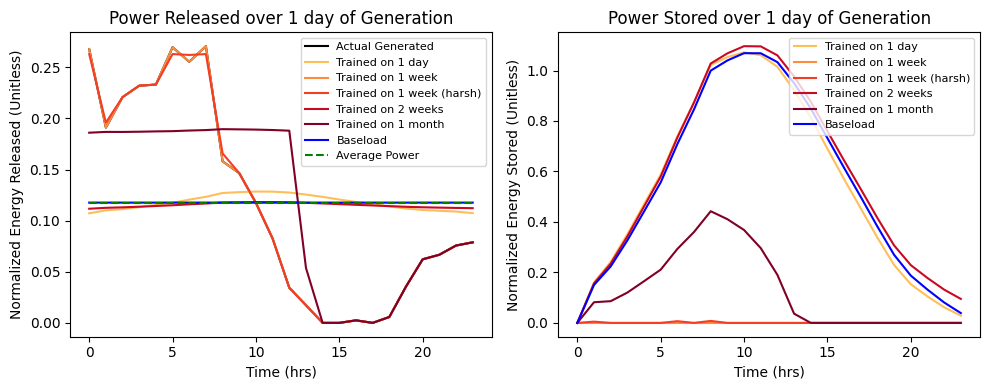

Length of dataset: 168


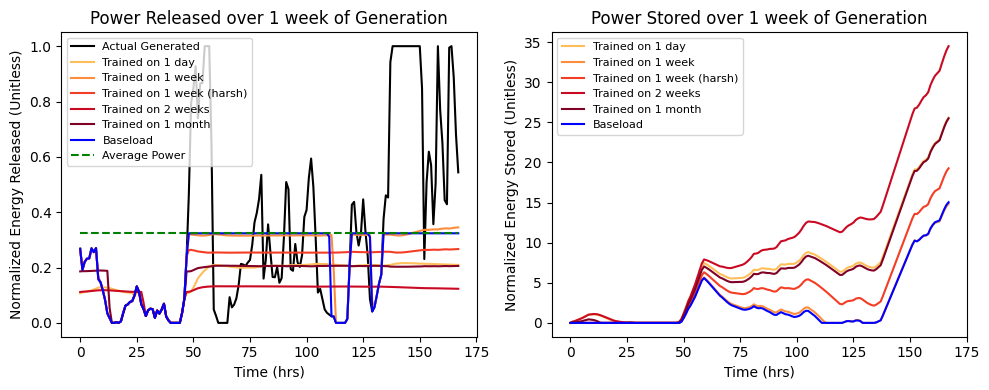

Length of dataset: 720


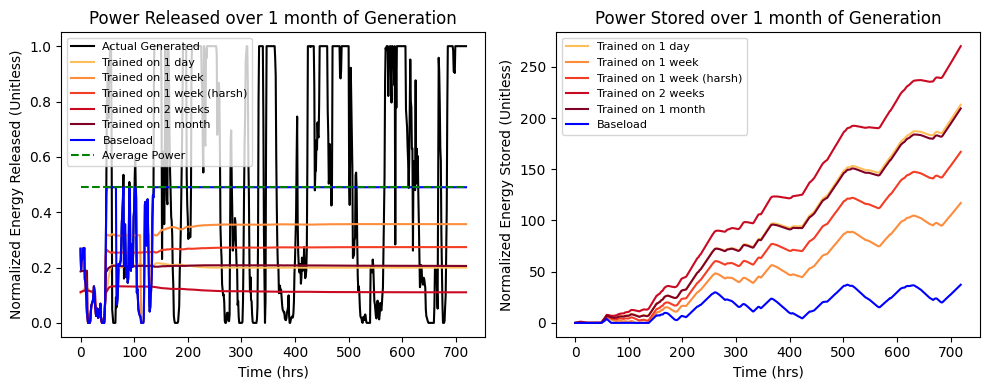

Length of dataset: 8760


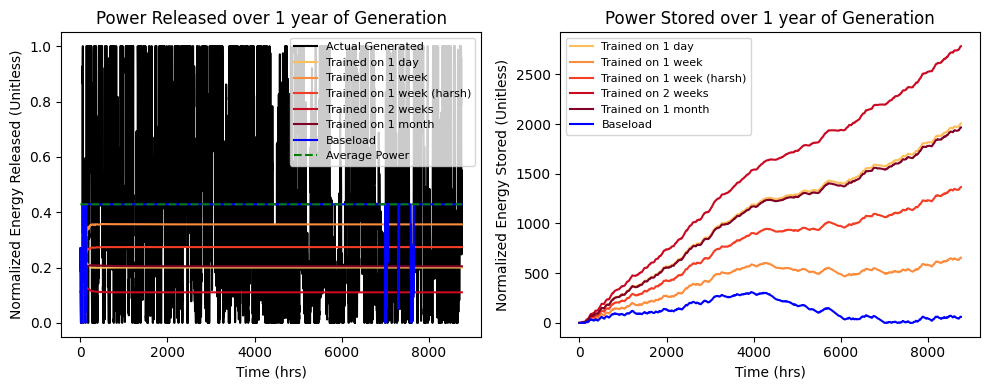

Length of dataset: 34861


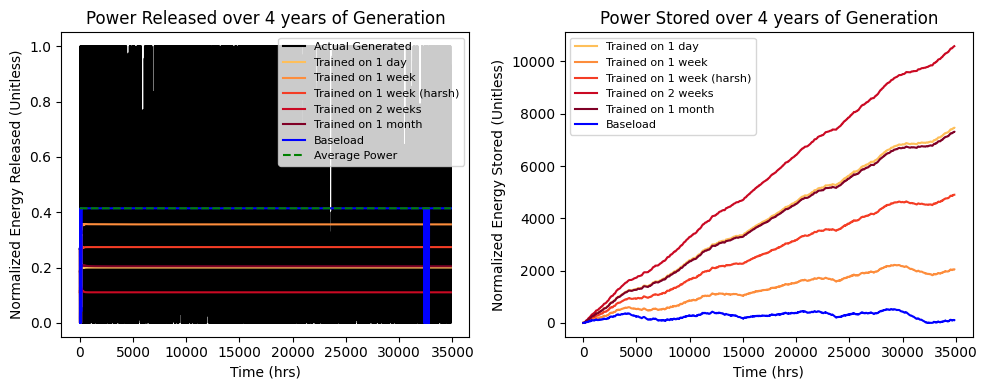

In [6]:
# Time scales for applying strategy
scales = ['1 day', '1 week', '1 month', '1 year', '4 years']
upper_dataset_bounds = [24, 24 * 7, 24 * 30, 24 * 365, len(raw_dataset)]

# Models available to test against (excluding baseline)
models = [model_1day_bl, model_1week_bl, model_1week_bl_harsh, model_2week_bl, model_1month_bl]
model_training_lengths = ['1 day', '1 week', '1 week (harsh)', '2 weeks', '1 month']

S = len(scales)
M = len(models)

# We compute these M+2 times because we compute the VF,COVE for each model, as well as for the raw power and baseload
vfs = np.zeros(shape=(S, M+2))
coves = np.zeros(shape=(S, M+2))

for i in range(S):
    upper_dataset_bound = upper_dataset_bounds[i]
    scale = scales[i]
    dataset = raw_dataset[:upper_dataset_bound]
    print(f'Length of dataset: {len(dataset)}')
    power = dataset[:,0].detach().cpu().numpy().squeeze()
    price = dataset[:,1].detach().cpu().numpy().squeeze()
    x = np.arange(0, len(dataset))

    #Compute raw VF and COVE (no storage)
    vfs[i, 0] = value_factor(power, price)
    coves[i, 0] = cove(power, price)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    cmap = plt.get_cmap('YlOrRd', M + 2)

    avg_power = np.repeat(np.mean(power), len(x))
    ax1.plot(x, power, 'black', label='Actual Generated')
    for j in range(M):
        model = models[j]
        model_training_length = model_training_lengths[j]

        pred = model(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
        released = pred[:,0]
        stored = pred[:,1]

        #Compute VF and COVE with storage strategy
        vfs[i, j+1] = value_factor(released, price)
        coves[i, j+1] = cove(released, price)

        ax1.plot(x, released, color=cmap(j + 2), label=f'Trained on {model_training_length}')
        ax2.plot(x, stored, color=cmap(j + 2), label=f'Trained on {model_training_length}')
    # Get baseload performance
    baseload_released, baseload_stored = base_load(power)
    #Compute VF and COVE with baseload strategy
    vfs[i, M+1] = value_factor(baseload_released, price)
    coves[i, M+1] = cove(baseload_released, price)
    ax1.plot(x, baseload_released, 'b', label='Baseload')
    ax2.plot(x, baseload_stored, 'b', label='Baseload')
    # Display average power over other curves
    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Normalized Energy Released (Unitless)')
    ax1.set_title(f'Power Released over {scale} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Normalized Energy Stored (Unitless)')
    ax2.set_title(f'Power Stored over {scale} of Generation')
    ax2.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [7]:
strategy_names = ["Raw", "COVE-NN-1day", "COVE-NN-1week", "COVE-NN-2week", "COVE-NN-1month", "Baseload"]
for i in range(S):
    print(f'Performance for {scales[i]} of power generation')
    metrics = {
        'Strategy': strategy_names,
        'VF': vfs[i,:],
        'COVE': coves[i,:],
        'Beats Baseload in VF?': vfs[i,:] > vfs[i,-1],
        'Beats Baseload in COVE?': coves[i,:] < coves[i,-1]
    }
    df = pd.DataFrame(metrics)
    print(tabulate(df, headers='keys', tablefmt='psql'))

Performance for 1 day of power generation


ValueError: All arrays must be of the same length

In [ ]:
model_1week_no_storage, _, _ = load_experiment('8584e4f1-d633-4c50-bdab-7056831c04ab', '../../data/processed/dataset_2018-21.csv')
model_1week_10, _, _ = load_experiment('3e8a31e5-ba5c-46a6-a443-4f28ed296264', '../../data/processed/dataset_2018-21.csv')
model_1week_5, _, _ = load_experiment('9ed42c95-2a82-4b82-9644-550b9d013271', '../../data/processed/dataset_2018-21.csv')
model_1week_4, _, _ = load_experiment('acbfb497-203b-4a1d-9cd3-6d45d1bceb68', '../../data/processed/dataset_2018-21.csv')
model_1week_3, _, _ = load_experiment('88ed5dc5-dc27-41bc-9ecb-2dc4b071d24f', '../../data/processed/dataset_2018-21.csv')
model_1week_1, _, _ = load_experiment('e5d682b1-15aa-418e-b3cd-cfe6c89dd4a3', '../../data/processed/dataset_2018-21.csv')
model_1week_0, _, _ = load_experiment('8ec34579-fc46-4b52-882a-cbac192115db', '../../data/processed/dataset_2018-21.csv')

/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForeca

Length of dataset: 24


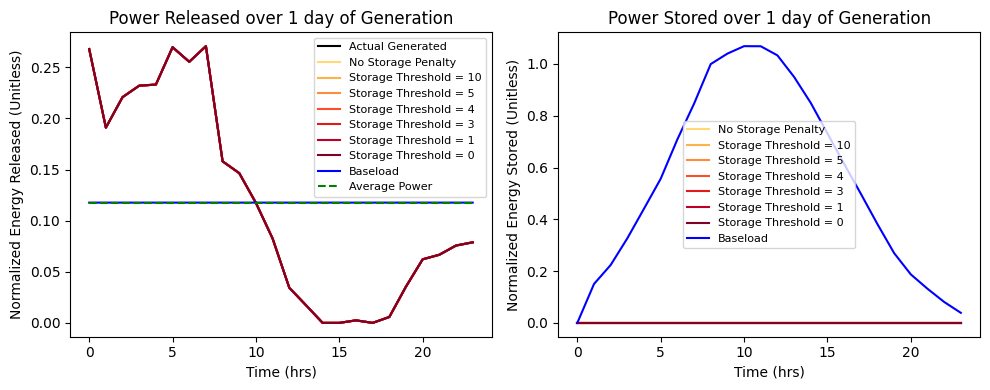

Length of dataset: 168


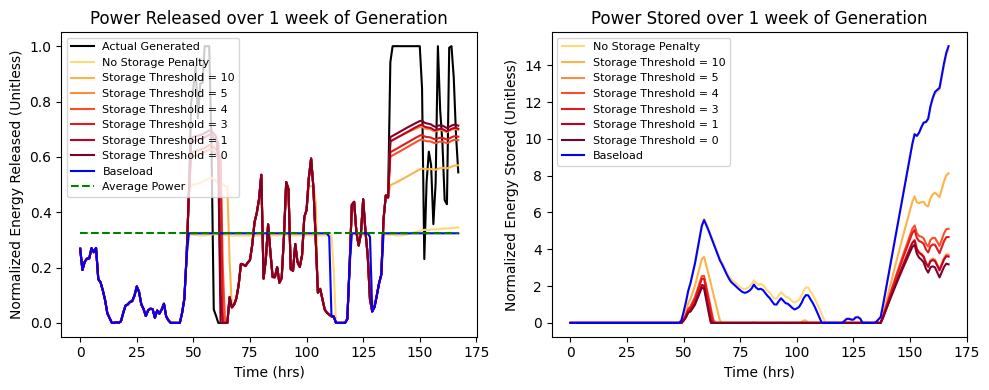

Length of dataset: 720


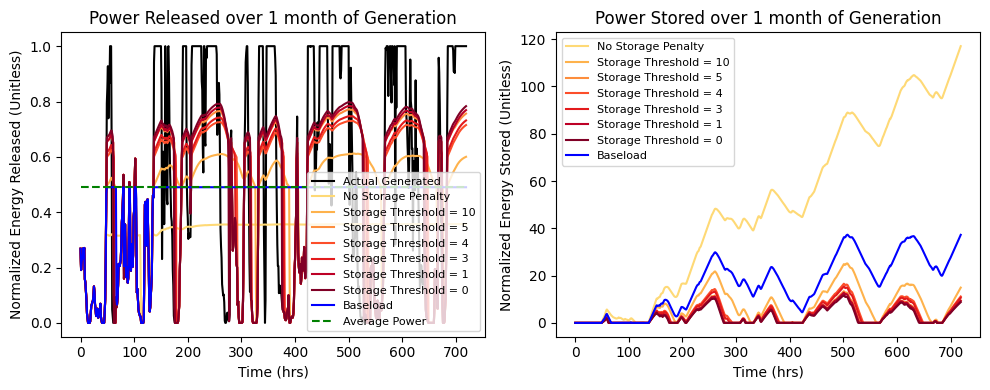

Length of dataset: 8760


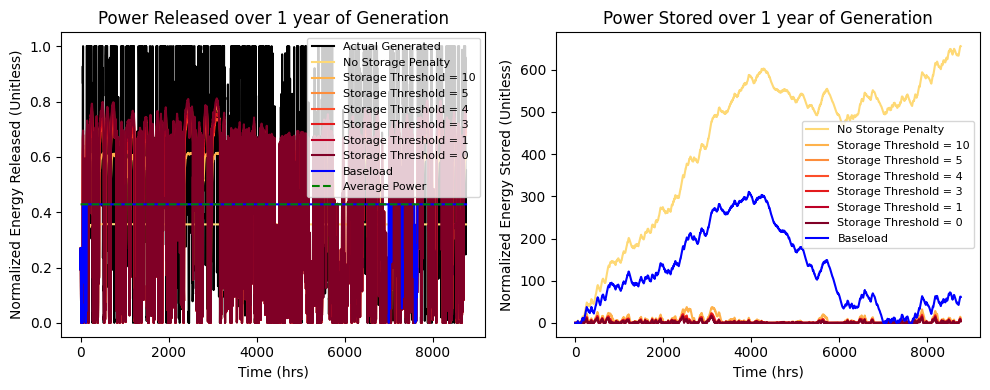

Length of dataset: 34861


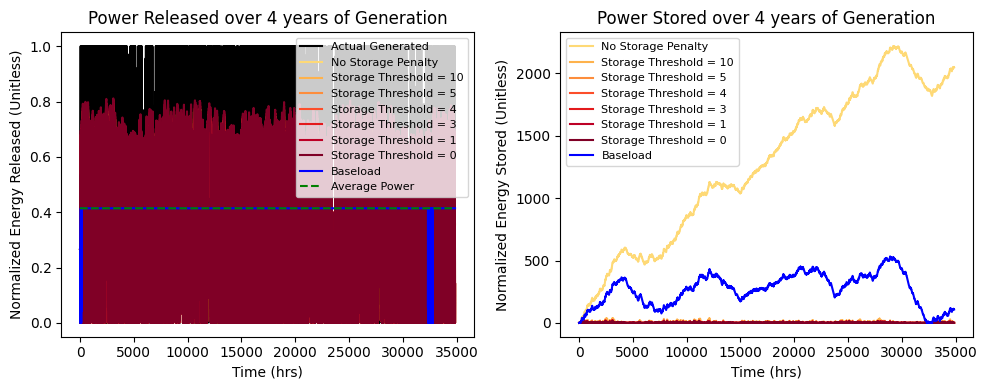

In [ ]:
# Time scales for applying strategy
scales = ['1 day', '1 week', '1 month', '1 year', '4 years']
upper_dataset_bounds = [24, 24 * 7, 24 * 30, 24 * 365, len(raw_dataset)]

# Models available to test against (excluding baseline)
models = [model_1week_no_storage, model_1week_10, model_1week_5, model_1week_4, model_1week_3, model_1week_1, model_1week_0]
model_storage_thresholds = ['No Storage Penalty', 
                            'Storage Threshold = 10', 
                            'Storage Threshold = 5', 
                            'Storage Threshold = 4', 
                            'Storage Threshold = 3', 
                            'Storage Threshold = 1', 
                            'Storage Threshold = 0']

S = len(scales)
M = len(models)

# We compute these M+2 times because we compute the VF,COVE for each model, as well as for the raw power and baseload
vfs = np.zeros(shape=(S, M+2))
coves = np.zeros(shape=(S, M+2))

for i in range(S):
    upper_dataset_bound = upper_dataset_bounds[i]
    scale = scales[i]
    dataset = raw_dataset[:upper_dataset_bound]
    print(f'Length of dataset: {len(dataset)}')
    power = dataset[:,0].detach().cpu().numpy().squeeze()
    price = dataset[:,1].detach().cpu().numpy().squeeze()
    x = np.arange(0, len(dataset))

    #Compute raw VF and COVE (no storage)
    vfs[i, 0] = value_factor(power, price)
    coves[i, 0] = cove(power, price)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    cmap = plt.get_cmap('YlOrRd', M + 2)

    avg_power = np.repeat(np.mean(power), len(x))
    ax1.plot(x, power, 'black', label='Actual Generated')
    for j in range(M):
        model = models[j]
        model_storage_threshold = model_storage_thresholds[j]

        pred = model(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
        released = pred[:,0]
        stored = pred[:,1]

        #Compute VF and COVE with storage strategy
        vfs[i, j+1] = value_factor(released, price)
        coves[i, j+1] = cove(released, price)

        ax1.plot(x, released, color=cmap(j + 2), label=model_storage_threshold)
        ax2.plot(x, stored, color=cmap(j + 2), label=model_storage_threshold)
    # Get baseload performance
    baseload_released, baseload_stored = base_load(power)
    #Compute VF and COVE with baseload strategy
    vfs[i, M+1] = value_factor(baseload_released, price)
    coves[i, M+1] = cove(baseload_released, price)
    ax1.plot(x, baseload_released, 'b', label='Baseload')
    ax2.plot(x, baseload_stored, 'b', label='Baseload')
    # Display average power over other curves
    ax1.plot(x, avg_power, '--g', label='Average Power')
    # Show plots
    ax1.set_xlabel('Time (hrs)')
    ax1.set_ylabel('Normalized Energy Released (Unitless)')
    ax1.set_title(f'Power Released over {scale} of Generation')
    ax1.legend(fontsize=8)

    ax2.set_xlabel('Time (hrs)')
    ax2.set_ylabel('Normalized Energy Stored (Unitless)')
    ax2.set_title(f'Power Stored over {scale} of Generation')
    ax2.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [ ]:
strategy_names = ["Raw", "COVE-NN", "COVE-NN-10", "COVE-NN-5", "COVE-NN-4", "COVE-NN-3", "COVE-NN-1", "COVE-NN-0", "Baseload"]
for i in range(S):
    print(f'Performance for {scales[i]} of power generation')
    metrics = {
        'Strategy': strategy_names,
        'VF': vfs[i,:],
        'COVE': coves[i,:],
        'Beats Baseload in VF?': vfs[i,:] > vfs[i,-1],
        'Beats Baseload in COVE?': coves[i,:] < coves[i,-1]
    }
    df = pd.DataFrame(metrics)
    print(tabulate(df, headers='keys', tablefmt='psql'))

Performance for 1 day of power generation
+----+------------+----------+---------+-------------------------+---------------------------+
|    | Strategy   |       VF |    COVE | Beats Baseload in VF?   | Beats Baseload in COVE?   |
|----+------------+----------+---------+-------------------------+---------------------------|
|  0 | Raw        | 0.943004 | 10.8424 | False                   | False                     |
|  1 | COVE-NN    | 0.943004 | 10.8424 | False                   | False                     |
|  2 | COVE-NN-10 | 0.943004 | 10.8424 | False                   | False                     |
|  3 | COVE-NN-5  | 0.943004 | 10.8424 | False                   | False                     |
|  4 | COVE-NN-4  | 0.943004 | 10.8424 | False                   | False                     |
|  5 | COVE-NN-3  | 0.943004 | 10.8424 | False                   | False                     |
|  6 | COVE-NN-1  | 0.943004 | 10.8424 | False                   | False                     |
|  7 | C

0.41416743


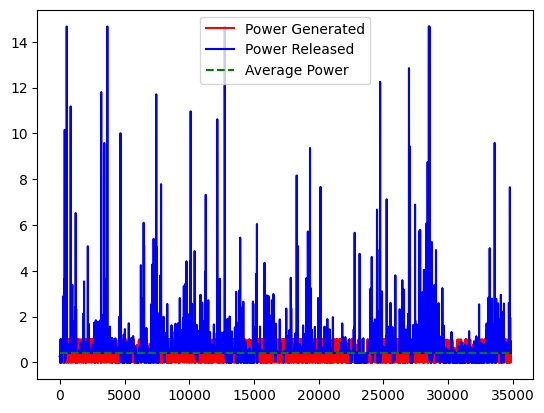

Raw VF: 0.5822171568870544
Modified Base Load VF: 1.8854987504563545
Modified Base Load COVE: 0.0013029092403614498


In [ ]:
base_load_released = base_load_modified(power, price)

avg = np.repeat(np.mean(power), len(x))
plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, base_load_released, 'b', label='Power Released')
plt.plot(x, avg, '--g', label='Average Power')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
after_vf = value_factor(base_load_released, price)
after_cove = cove(base_load_released, price)

print(f'Raw VF: {before_vf}')
print(f'Modified Base Load VF: {after_vf}')
print(f'Modified Base Load COVE: {after_cove}')